# Análise de Dados e Machine Learning no Agronegócio

Este projeto trabalha com uma base de dados agrícola contendo informações sobre solo, clima e culturas recomendadas.

A ideia principal é analisar esses dados para entender como variáveis como nitrogênio, fósforo, potássio, temperatura, umidade, pH e chuva se relacionam com diferentes culturas agrícolas.

Além da análise exploratória, também foram testados modelos de Machine Learning para prever qual cultura seria mais adequada a partir dessas condições. Com isso, o projeto mostra uma aplicação prática dos dados no contexto do agronegócio.

## 1. Importação das bibliotecas

Nesta etapa são importadas as bibliotecas usadas para análise dos dados, visualização dos gráficos e criação dos modelos de Machine Learning.

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

## 2. Descrição da base de dados

A base utilizada foi o arquivo `Atividade_Cap10_produtos_agricolas.csv`, que contém registros com informações de solo, clima e a cultura recomendada para cada conjunto de condições.

As colunas da base são:

- **N**: quantidade de nitrogênio no solo;
- **P**: quantidade de fósforo no solo;
- **K**: quantidade de potássio no solo;
- **temperature**: temperatura;
- **humidity**: umidade;
- **ph**: nível de acidez ou alcalinidade do solo;
- **rainfall**: índice de chuva;
- **label**: cultura agrícola recomendada.

Neste projeto, a coluna `label` será usada como o valor que os modelos devem prever.

## 3. Carregamento dos dados

Nesta etapa, a base é carregada e são feitas verificações iniciais para entender sua estrutura.

In [4]:
df = pd.read_csv("../assets/Atividade_Cap10_produtos_agricolas.csv")

In [5]:
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [6]:
df.shape

(2200, 8)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   str    
dtypes: float64(4), int64(3), str(1)
memory usage: 153.0 KB


In [8]:
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [9]:
df.isnull().sum()

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

In [10]:
df["label"].value_counts()

label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64

## 4. Conhecimento inicial dos dados

Antes de iniciar as análises, foi feita uma verificação geral da base para entender sua estrutura.

Foram observados o número de linhas e colunas, os tipos de dados, a presença de valores ausentes e a quantidade de registros para cada cultura.

A base possui 2200 registros, 8 colunas e não apresenta valores nulos. Também foi observado que as culturas possuem a mesma quantidade de registros, o que ajuda no treinamento dos modelos.

## 5. Análise exploratória dos dados

Nesta etapa, foram criados gráficos para observar melhor o comportamento das variáveis da base.

A análise exploratória ajuda a identificar padrões, diferenças entre culturas e possíveis relações entre as variáveis de solo e clima.

Foram analisadas variáveis como temperatura, umidade, chuva, pH e nutrientes do solo, além da distribuição das culturas presentes na base.

### 5.1 Distribuição das culturas

O gráfico abaixo mostra a quantidade de registros para cada cultura presente na base.

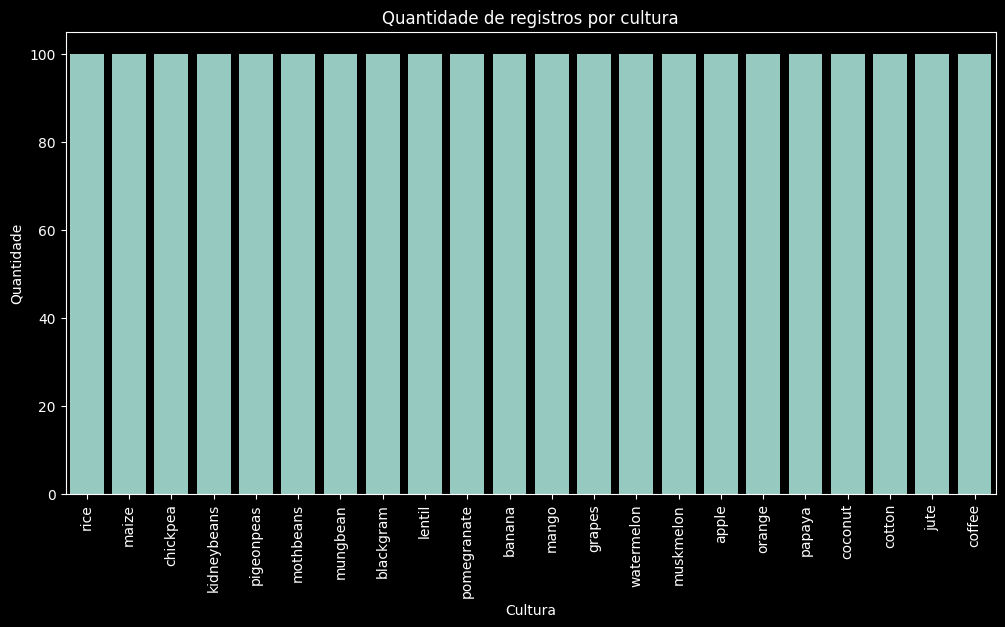

In [11]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x="label", order=df["label"].value_counts().index)

plt.title("Quantidade de registros por cultura")
plt.xlabel("Cultura")
plt.ylabel("Quantidade")
plt.xticks(rotation=90)
plt.show()

O gráfico mostra que as culturas possuem a mesma quantidade de registros. Isso indica que a base está balanceada, o que é positivo para a etapa de treinamento dos modelos, pois nenhuma cultura aparece com mais exemplos do que as outras.

### 5.2 Correlação entre variáveis numéricas

A matriz de correlação ajuda a observar a relação entre as variáveis numéricas da base.

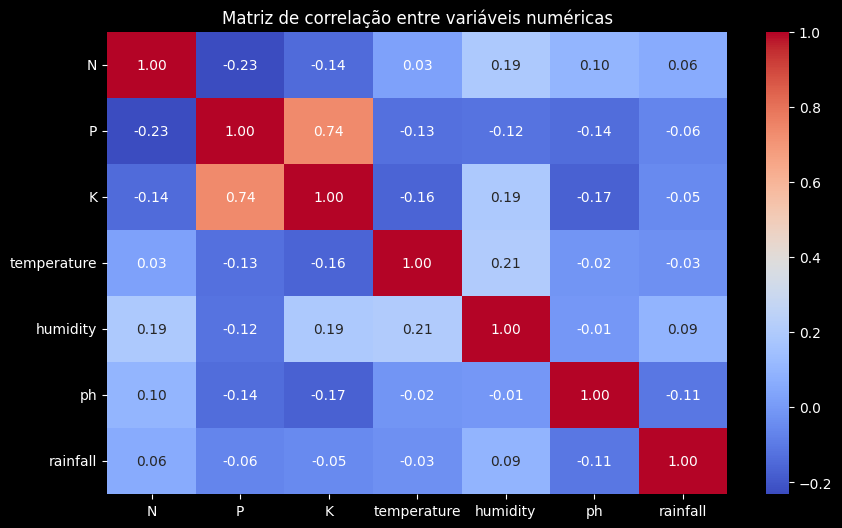

In [12]:
plt.figure(figsize=(10, 6))

correlacao = df.drop(columns=["label"]).corr()

sns.heatmap(correlacao, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Matriz de correlação entre variáveis numéricas")
plt.show()

A matriz de correlação permite observar se algumas variáveis possuem relação mais forte entre si. Mesmo que a correlação não determine diretamente a cultura recomendada, ela ajuda a entender melhor o comportamento geral dos dados.

### 5.3 Distribuição da temperatura por cultura

O gráfico abaixo compara a variável `temperature` entre as diferentes culturas.

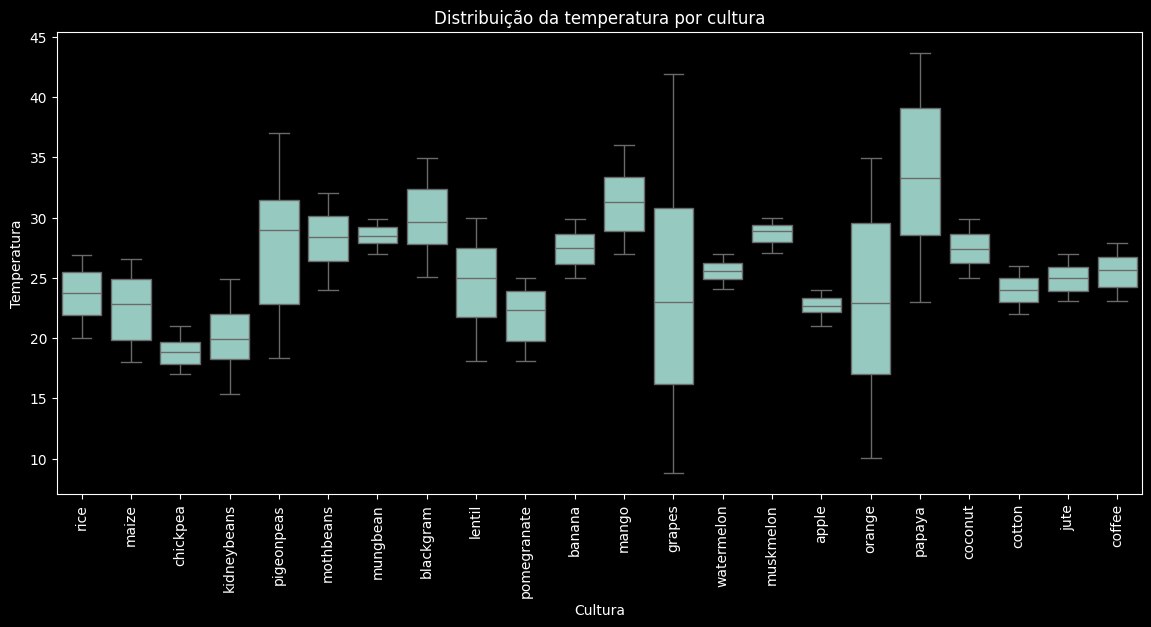

In [13]:
plt.figure(figsize=(14, 6))
sns.boxplot(data=df, x="label", y="temperature")

plt.title("Distribuição da temperatura por cultura")
plt.xlabel("Cultura")
plt.ylabel("Temperatura")
plt.xticks(rotation=90)
plt.show()

A temperatura apresenta variações entre as culturas. Algumas aparecem em faixas mais altas, enquanto outras estão concentradas em temperaturas menores. Isso indica que a temperatura pode ser uma variável importante para diferenciar culturas.

### 5.4 Distribuição da umidade por cultura

O gráfico abaixo compara a variável `humidity` entre as diferentes culturas.

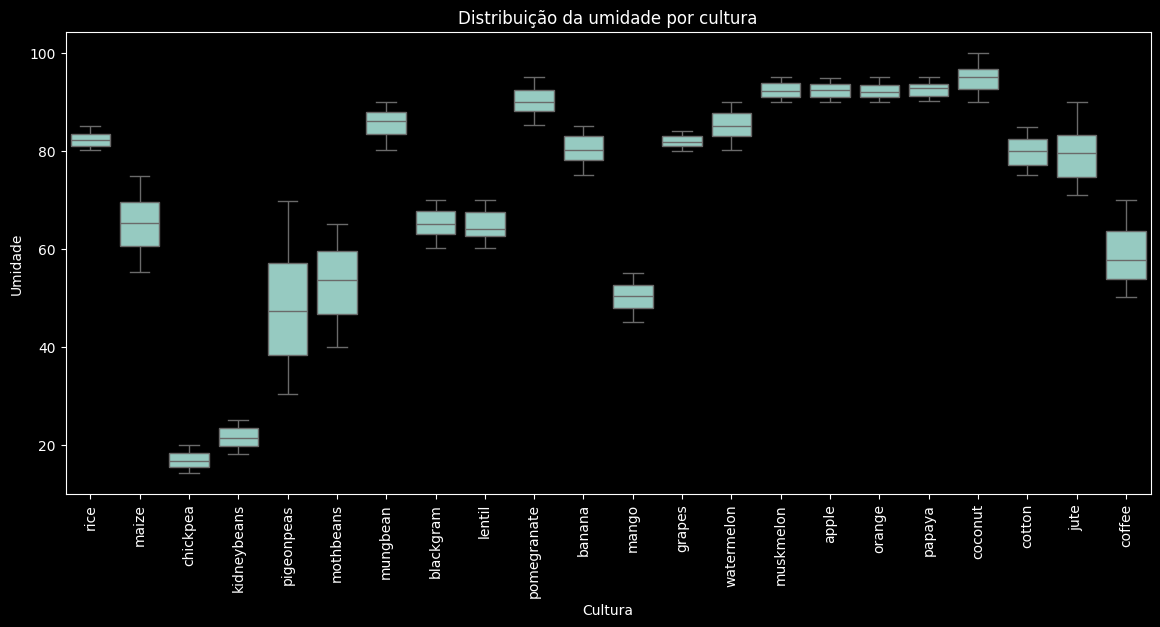

In [14]:
plt.figure(figsize=(14, 6))
sns.boxplot(data=df, x="label", y="humidity")

plt.title("Distribuição da umidade por cultura")
plt.xlabel("Cultura")
plt.ylabel("Umidade")
plt.xticks(rotation=90)
plt.show()

A umidade também apresenta diferenças entre as culturas. Algumas culturas aparecem mais associadas a ambientes úmidos, enquanto outras aparecem em condições de menor umidade.

### 5.5 Distribuição da chuva por cultura

O gráfico abaixo compara a variável `rainfall` entre as diferentes culturas.

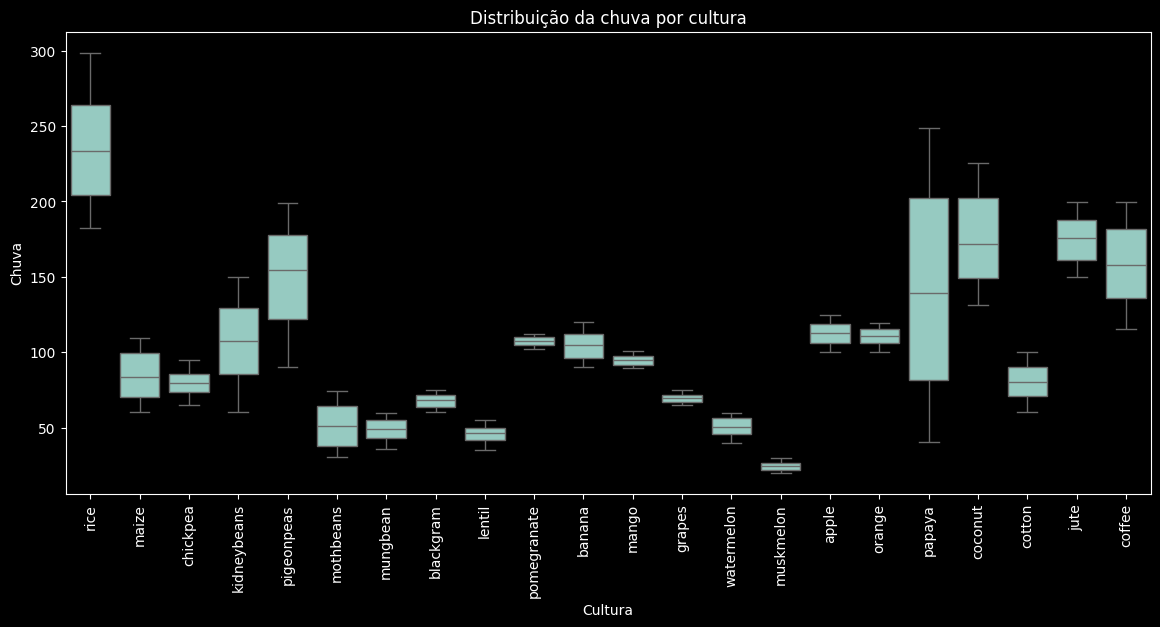

In [15]:
plt.figure(figsize=(14, 6))
sns.boxplot(data=df, x="label", y="rainfall")

plt.title("Distribuição da chuva por cultura")
plt.xlabel("Cultura")
plt.ylabel("Chuva")
plt.xticks(rotation=90)
plt.show()

A quantidade de chuva varia bastante entre algumas culturas. Essa variável é importante porque influencia diretamente o desenvolvimento das plantas e pode ajudar o modelo a diferenciar culturas que precisam de maior ou menor volume de água.

### 5.6 Distribuição do pH por cultura

O gráfico abaixo compara a variável `ph` entre as diferentes culturas.

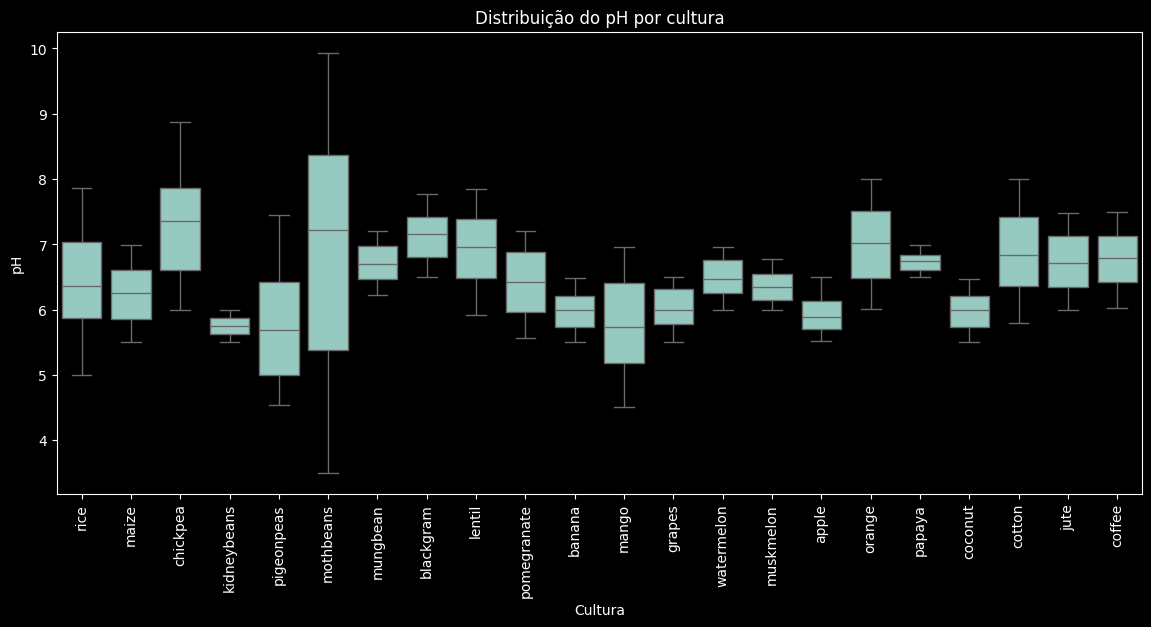

In [16]:
plt.figure(figsize=(14, 6))
sns.boxplot(data=df, x="label", y="ph")

plt.title("Distribuição do pH por cultura")
plt.xlabel("Cultura")
plt.ylabel("pH")
plt.xticks(rotation=90)
plt.show()

O pH mostra diferenças entre algumas culturas, indicando que determinadas plantas podem estar mais associadas a solos mais ácidos ou mais próximos da neutralidade.

## 6. Perfil ideal de solo e clima para três culturas

Para comparar melhor as características das culturas, foram escolhidas três delas: `rice`, `maize` e `coffee`.

A comparação foi feita usando a média das variáveis de solo e clima para cada cultura. Dessa forma, foi possível observar quais condições aparecem com mais frequência para cada uma.

Essa análise ajuda a entender que cada cultura possui um perfil diferente e pode depender mais ou menos de fatores como chuva, umidade, temperatura e nutrientes do solo.

In [17]:
df["label"].unique()

<ArrowStringArray>
[       'rice',       'maize',    'chickpea', 'kidneybeans',  'pigeonpeas',
   'mothbeans',    'mungbean',   'blackgram',      'lentil', 'pomegranate',
      'banana',       'mango',      'grapes',  'watermelon',   'muskmelon',
       'apple',      'orange',      'papaya',     'coconut',      'cotton',
        'jute',      'coffee']
Length: 22, dtype: str

In [18]:
culturas_escolhidas = ["rice", "maize", "coffee"]

df_culturas = df[df["label"].isin(culturas_escolhidas)]

df_culturas.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [19]:
perfil_ideal = df_culturas.groupby("label").mean(numeric_only=True)

perfil_ideal

,N,P,K,temperature,humidity,ph,rainfall
label,,,,,,,
coffee,101.20,28.74,29.94,25.540477,58.869846,6.790308,158.066295
maize,77.76,48.44,19.79,22.389204,65.092249,6.245190,84.766988
rice,79.89,47.58,39.87,23.689332,82.272822,6.425471,236.181114


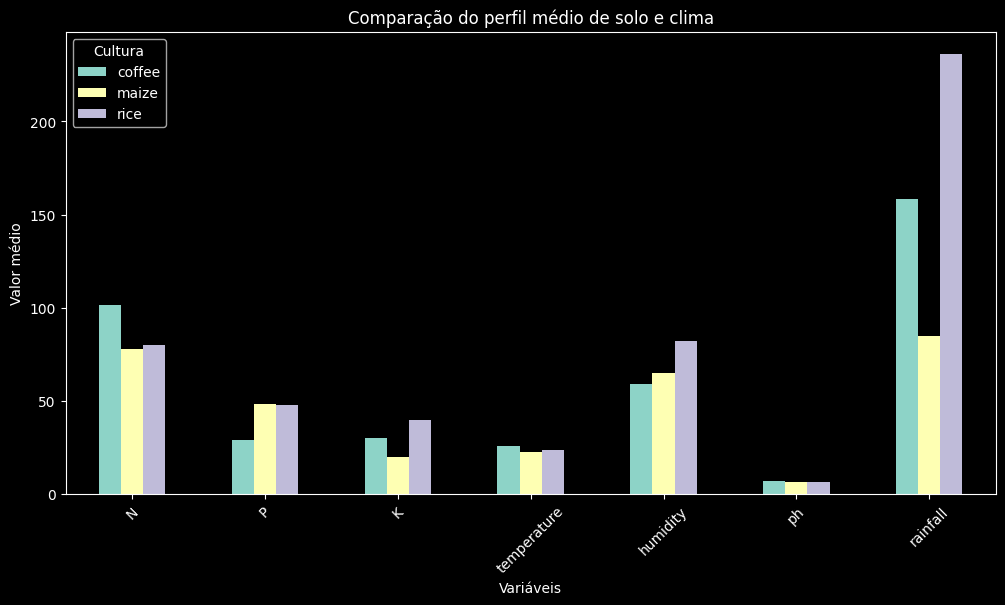

In [20]:
perfil_ideal.T.plot(kind="bar", figsize=(12, 6))

plt.title("Comparação do perfil médio de solo e clima")
plt.xlabel("Variáveis")
plt.ylabel("Valor médio")
plt.xticks(rotation=45)
plt.legend(title="Cultura")
plt.show()

### Comparação entre as culturas escolhidas

Ao comparar `rice`, `maize` e `coffee`, é possível perceber diferenças importantes entre os perfis de cada cultura.

A cultura `rice` apresenta médias mais altas de umidade e chuva, indicando maior relação com ambientes mais úmidos.

A cultura `maize` possui valores mais moderados, principalmente em relação à chuva e umidade.

Já a cultura `coffee` apresenta maior média de nitrogênio entre as três culturas analisadas, além de uma quantidade de chuva maior que `maize`, mas menor que `rice`.

Essa comparação mostra que as culturas possuem características diferentes e que essas variáveis podem ajudar na recomendação da cultura mais adequada.

### Comparação separada por variável

Os gráficos abaixo mostram a média de cada variável para as três culturas escolhidas.

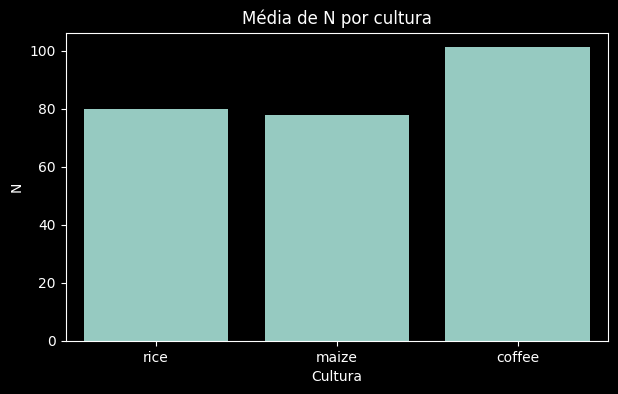

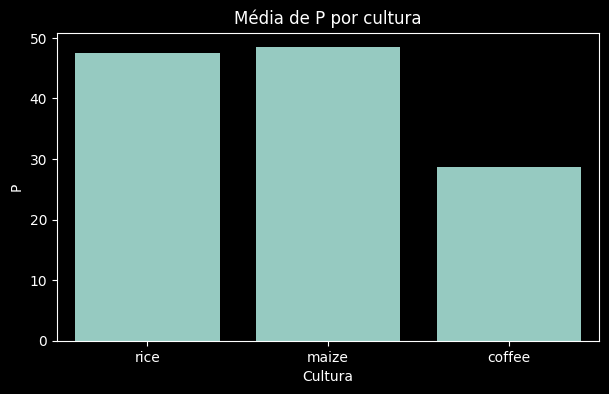

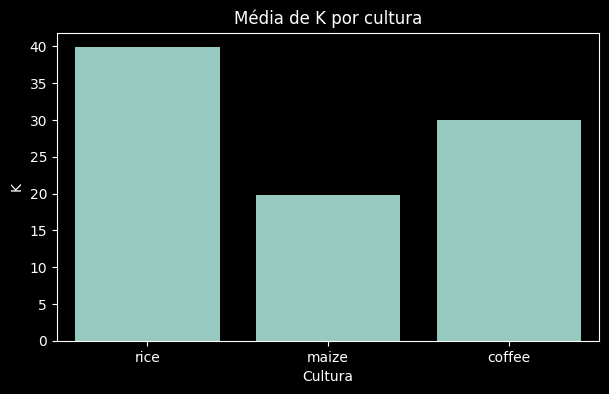

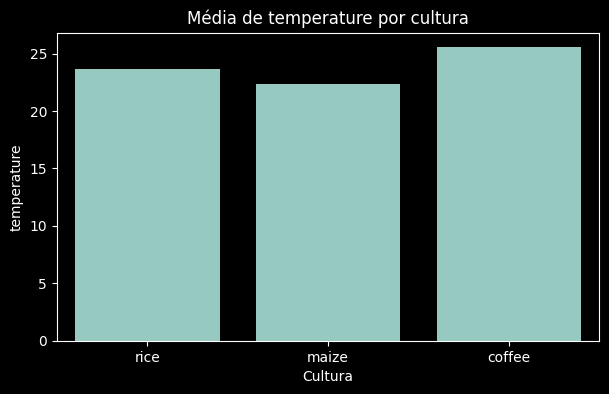

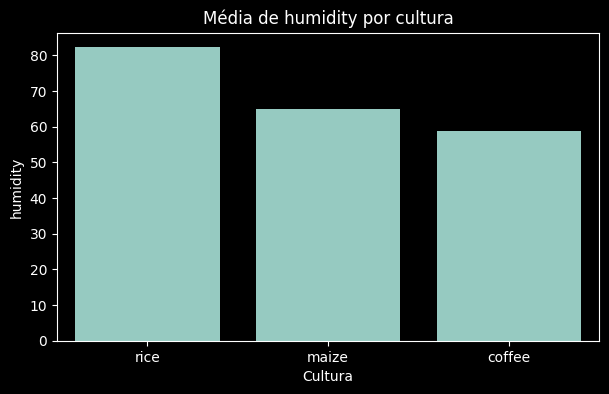

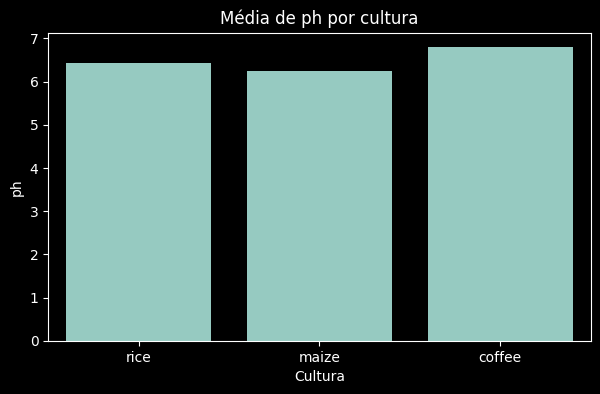

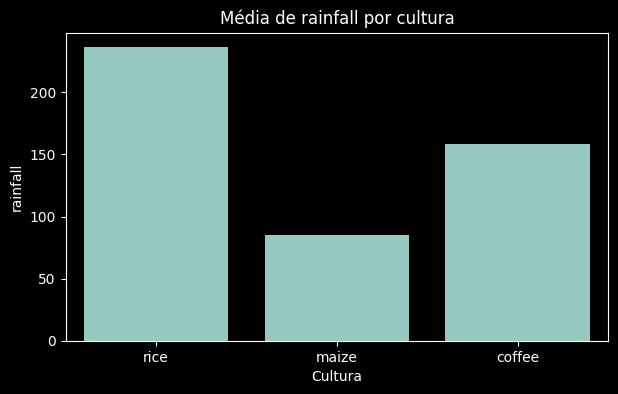

In [21]:
variaveis = ["N", "P", "K", "temperature", "humidity", "ph", "rainfall"]

for variavel in variaveis:
    plt.figure(figsize=(7, 4))
    sns.barplot(data=df_culturas, x="label", y=variavel, errorbar=None)

    plt.title(f"Média de {variavel} por cultura")
    plt.xlabel("Cultura")
    plt.ylabel(variavel)
    plt.show()

## 7. Preparação dos dados

Para treinar os modelos, a base foi separada entre variáveis de entrada e variável alvo.

As variáveis de entrada foram `N`, `P`, `K`, `temperature`, `humidity`, `ph` e `rainfall`.

A variável alvo foi `label`, que representa a cultura recomendada.

Como a coluna `label` está em formato de texto, ela foi convertida para valores numéricos antes do treinamento. Depois disso, os dados foram divididos em treino e teste.

In [22]:
X = df.drop(columns=["label"])
y = df["label"]

In [23]:
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

## 8. Modelagem preditiva

Nesta etapa, foram treinados cinco modelos de Machine Learning com algoritmos diferentes.

O objetivo foi comparar o desempenho de cada modelo na previsão da cultura recomendada a partir das informações de solo e clima.

Os modelos utilizados foram:

- Regressão Logística;
- Árvore de Decisão;
- Random Forest;
- KNN;
- SVM.

In [25]:
modelos = {
    "Regressão Logística": Pipeline([
        ("scaler", StandardScaler()),
        ("modelo", LogisticRegression(max_iter=1000))
    ]),

    "Árvore de Decisão": DecisionTreeClassifier(random_state=42),

    "Random Forest": RandomForestClassifier(random_state=42),

    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("modelo", KNeighborsClassifier())
    ]),

    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("modelo", SVC())
    ])
}

## 9. Avaliação dos modelos

Depois do treinamento, os modelos foram avaliados usando métricas de classificação.

Foram observadas métricas como acurácia, precision, recall e f1-score. A acurácia mostra a quantidade geral de acertos, enquanto as outras métricas ajudam a analisar melhor o desempenho do modelo para cada cultura.

Também foi usada a matriz de confusão para visualizar os acertos e erros do melhor modelo.

In [26]:
resultados = []

for nome, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)

    acuracia = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="weighted")
    recall = recall_score(y_test, y_pred, average="weighted")
    f1 = f1_score(y_test, y_pred, average="weighted")

    resultados.append({
        "Modelo": nome,
        "Acurácia": acuracia,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1
    })

    print(f"Modelo: {nome}")
    print(f"Acurácia: {acuracia:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-score: {f1:.4f}")
    print()
    print(classification_report(y_test, y_pred, target_names=encoder.classes_))
    print("-" * 80)

Modelo: Regressão Logística
Acurácia: 0.9727
Precision: 0.9740
Recall: 0.9727
F1-score: 0.9725

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       0.95      1.00      0.98        20
    chickpea       1.00      1.00      1.00        20
     coconut       0.95      1.00      0.98        20
      coffee       1.00      1.00      1.00        20
      cotton       0.95      1.00      0.98        20
      grapes       1.00      1.00      1.00        20
        jute       0.83      1.00      0.91        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       0.94      0.85      0.89        20
       maize       1.00      0.95      0.97        20
       mango       0.95      1.00      0.98        20
   mothbeans       0.90      0.90      0.90        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      

### Comparação dos resultados

A tabela abaixo organiza as métricas dos modelos para facilitar a comparação.

In [27]:
df_resultados = pd.DataFrame(resultados)

df_resultados = df_resultados.sort_values(by="Acurácia", ascending=False)

df_resultados

,Modelo,Acurácia,Precision,Recall,F1-score
2,Random Forest,0.995455,0.995671,0.995455,0.995452
4,SVM,0.984091,0.985610,0.984091,0.984038
1,Árvore de Decisão,0.979545,0.980598,0.979545,0.979423
3,KNN,0.979545,0.980356,0.979545,0.979283
0,Regressão Logística,0.972727,0.974022,0.972727,0.972464


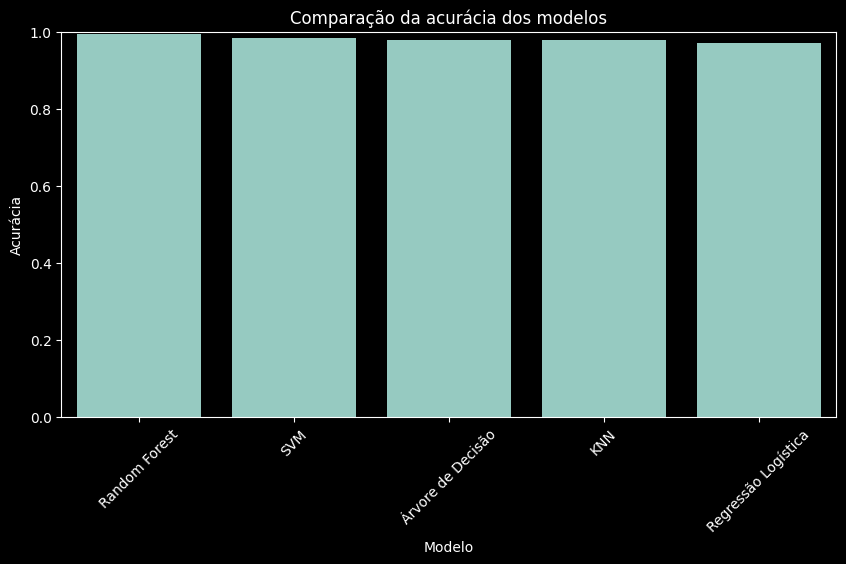

In [28]:
plt.figure(figsize=(10, 5))

sns.barplot(data=df_resultados, x="Modelo", y="Acurácia")

plt.title("Comparação da acurácia dos modelos")
plt.xlabel("Modelo")
plt.ylabel("Acurácia")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.show()

In [29]:
melhor_modelo_nome = df_resultados.iloc[0]["Modelo"]
melhor_modelo_nome

'Random Forest'

In [30]:
melhor_modelo = modelos[melhor_modelo_nome]

y_pred_melhor = melhor_modelo.predict(X_test)

### Matriz de confusão do melhor modelo

A matriz de confusão permite observar quais classes foram previstas corretamente e quais foram confundidas pelo modelo.

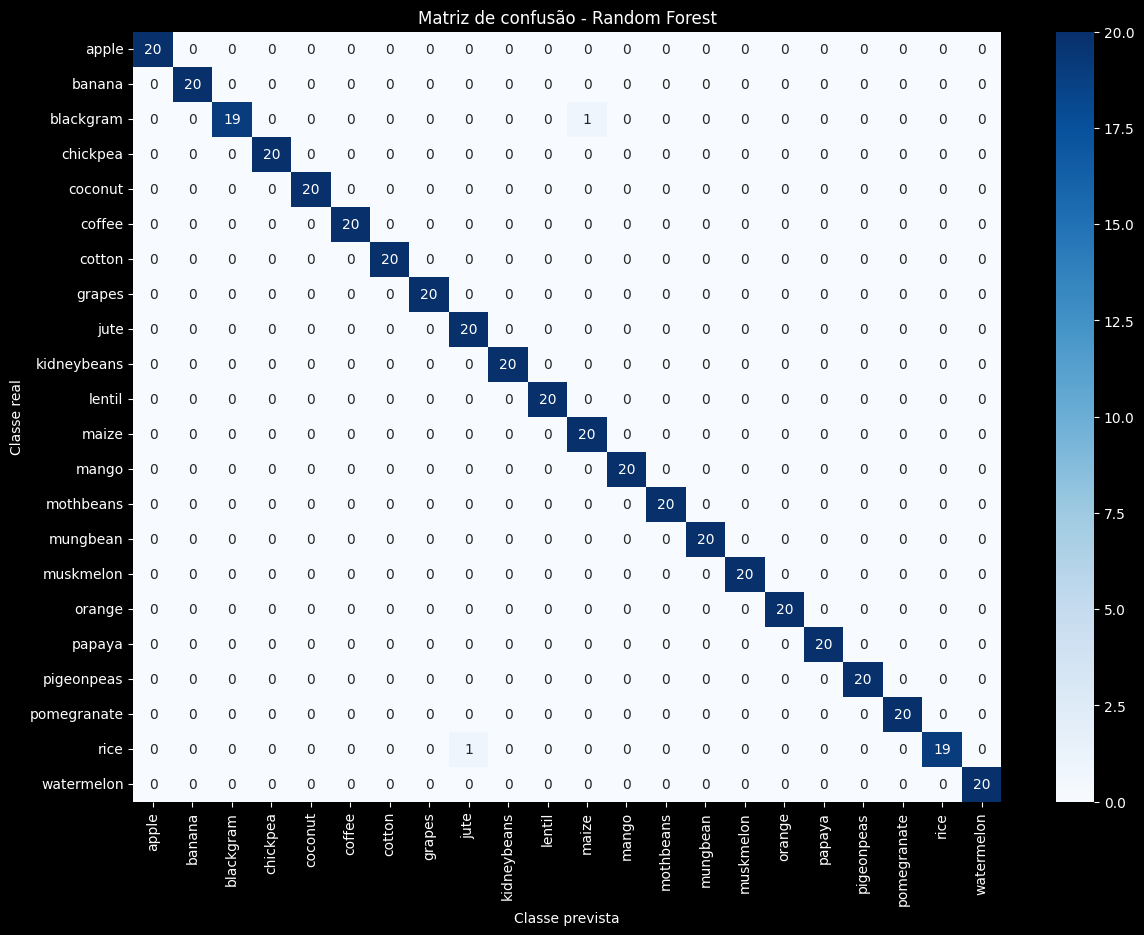

In [31]:
matriz = confusion_matrix(y_test, y_pred_melhor)

plt.figure(figsize=(14, 10))

sns.heatmap(
    matriz,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.title(f"Matriz de confusão - {melhor_modelo_nome}")
plt.xlabel("Classe prevista")
plt.ylabel("Classe real")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

### Teste manual de previsão

Nesta etapa, foi criado um exemplo com valores fictícios de solo e clima para verificar qual cultura o melhor modelo recomenda.

In [32]:
exemplo = pd.DataFrame({
    "N": [90],
    "P": [40],
    "K": [40],
    "temperature": [25],
    "humidity": [80],
    "ph": [6.5],
    "rainfall": [200]
})

previsao = melhor_modelo.predict(exemplo)

cultura_prevista = encoder.inverse_transform(previsao)

print("Cultura recomendada:", cultura_prevista[0])

Cultura recomendada: rice


In [33]:
melhor = df_resultados.iloc[0]
pior = df_resultados.iloc[-1]

print("Melhor modelo:", melhor["Modelo"])
print("Acurácia do melhor modelo:", round(melhor["Acurácia"], 4))

print("Pior modelo:", pior["Modelo"])
print("Acurácia do pior modelo:", round(pior["Acurácia"], 4))

Melhor modelo: Random Forest
Acurácia do melhor modelo: 0.9955
Pior modelo: Regressão Logística
Acurácia do pior modelo: 0.9727


## 10. Conclusão

Neste projeto, foi feita uma análise de dados agrícolas com informações sobre solo, clima e culturas recomendadas.

A análise exploratória ajudou a entender melhor a base, verificar a distribuição das culturas e observar diferenças entre variáveis como temperatura, umidade, chuva e pH.

Também foi comparado o perfil médio de três culturas: `rice`, `maize` e `coffee`. Essa etapa mostrou que cada cultura possui características diferentes em relação às condições de solo e clima.

Por fim, foram treinados cinco modelos de Machine Learning para prever a cultura recomendada. Os modelos foram avaliados e comparados por meio de métricas de classificação.

De modo geral, o projeto mostrou que dados agrícolas podem ser usados para gerar análises e apoiar recomendações no agronegócio.

> Depois de executar todos os modelos, complete o trecho abaixo com os resultados que aparecerem no seu notebook:
>
> O modelo com melhor resultado foi **[Random Forest]**, com acurácia de **[0.995455]**.
> O modelo com menor resultado foi **[Regressão logística]**, com acurácia de **[0.972727]**.